# SAS vs ESN — Mackey-Glass Benchmark  (100 data × 10 model seeds)

Side-by-side comparison of **saspy** (`SASForecaster` + `SASModel(InputProjector, DiagonalPoly)`)
vs a classic **ESN** (reservoirpy) on Mackey-Glass, run across a full grid of random seeds.

Both models: N=100 units, 50-step washout, h=1.

**ESN config:** `lr=1.0, sr=0.9`  — no leaking term; memory comes entirely from the spectral
radius.  This is structurally comparable to SAS where memory comes from the base eigenvalue
`p₀ ~ U(−0.9, +0.9)` with no separate carry-through term.  `sr=0.9` matches SAS `spectral_norm=0.9`.

**Readout:** both models use the **same** ridge CV (`saspy.ridge.ridge_cv_select`) so the
comparison is not contaminated by different regularisation strategies.

> **Note on `spectral_norm` in SAS:** the name is a slight misnomer.  For `DiagonalPoly` it is
> the *range bound* on the base scalar eigenvalue (`p₀ ~ U(−sn, sn)`), not the 2-norm of a
> matrix.  For `BlockLinearPoly` it is the true spectral norm of the degree-0 block.

- **10 data seeds** → 100 distinct Mackey-Glass trajectories (different initial conditions)
- **10 model seeds** → 10 independent reservoir initialisations per trajectory
- **100 independent evaluations per model**

In [22]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import time
import numpy as np
import matplotlib.pyplot as plt

import reservoirpy as rpy
from reservoirpy.nodes import Reservoir
from reservoirpy.datasets import mackey_glass

import jax
import jax.numpy as jnp

from saspy import SASForecaster, SASModel, InputProjector, DiagonalPoly
from saspy.engine import _forward, _step_once, _stream_scan
from saspy.ridge import ridge_cv_select, ridge_fit

try:
    rpy.verbosity(0)
except AttributeError:
    pass

print(f"reservoirpy : {rpy.__version__}")
print(f"JAX backend : {jax.default_backend()}")

reservoirpy : 0.4.1
JAX backend : cpu


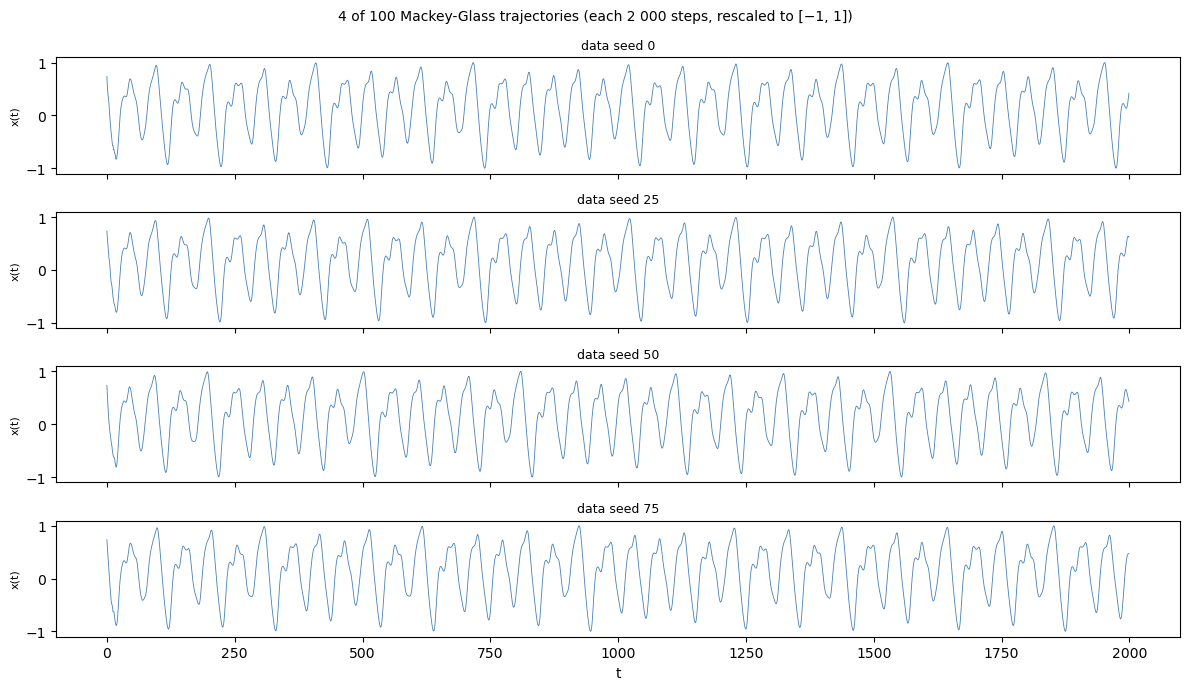

In [23]:
# Preview — 4 of the 100 data seeds to show trajectory variety
fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax, seed in zip(axes, [0, 25, 50, 75]):
    Xi = mackey_glass(2000, seed=seed)
    Xi = 2 * (Xi - Xi.min()) / (Xi.max() - Xi.min()) - 1
    ax.plot(Xi[:, 0], lw=0.6, color="steelblue")
    ax.set_ylabel("x(t)", fontsize=8)
    ax.set_title(f"data seed {seed}", fontsize=9)
axes[-1].set_xlabel("t")
plt.suptitle("4 of 100 Mackey-Glass trajectories (each 2 000 steps, rescaled to [−1, 1])",
             fontsize=10)
plt.tight_layout()
plt.show()

In [24]:
SPLIT       = 1600
WASHOUT     = 50
N           = 100
T_TEST      = 2000 - SPLIT          # 400
DATA_SEEDS  = list(range(10))
MODEL_SEEDS = list(range(10))

N_EVAL = len(DATA_SEEDS) * len(MODEL_SEEDS)
print(f"Grid : {len(DATA_SEEDS)} data × {len(MODEL_SEEDS)} model = {N_EVAL} evaluations / model")

Grid : 10 data × 10 model = 100 evaluations / model


## Compile SAS JIT kernels once (before the timed loop)

`_forward` (parallel scan) and `_stream_scan` (`lax.scan`) are both warmed here.
Cold-JIT cost is measured once and excluded from all per-run timings.

In [25]:
_X0 = mackey_glass(2000, seed=0)
_X0 = 2 * (_X0 - _X0.min()) / (_X0.max() - _X0.min()) - 1
_y0 = _X0[:SPLIT, 0]

_cold = SASForecaster(
    model=SASModel(
        projector=InputProjector(d=1, n_drivers=N),
        basis=DiagonalPoly(n=N, p_degree=1, q_degree=1),
    ),
    washout=WASHOUT, seed=0,
)
t0 = time.perf_counter()
_cold.fit(_y0, horizons=[1])
jax.block_until_ready(_cold._s_last)
t_sas_cold = time.perf_counter() - t0

_cold.update(0.0)                    # compile _step_once
jax.block_until_ready(_cold._s_last)

# warm-up _stream_scan (lax.scan batch-streaming variant)
# Multiple calls needed: JAX async dispatch means one call is not enough
# to guarantee the next measured call runs from a fully warm cache.
_z_warm = jnp.zeros((T_TEST, 1), dtype=jnp.float32)
_s_warm = jnp.zeros(N, dtype=jnp.float32)
for _ in range(4):
    _, _tmp = _stream_scan(_cold._model, _s_warm, _z_warm)
jax.block_until_ready(_tmp)
del _cold, _X0, _y0, _z_warm, _s_warm, _tmp

print(f"SAS cold JIT : {t_sas_cold * 1e3:.0f} ms  (one-time compile, excluded from benchmark)")

SAS cold JIT : 41 ms  (one-time compile, excluded from benchmark)


## Main experiment — 100 × 10 = 1 000 evaluations per model

In [26]:
all_esn = []          # 100 records
all_sas = []          # 100 records
esn_preds_d0 = []     # predictions for data_seed=0 only (prediction plot)
sas_preds_d0 = []
y_test_d0    = None

print(f"{'data':>6}  {'ESN RMSE':>12}  {'SAS RMSE':>12}")
print("-" * 36)

for d_seed in DATA_SEEDS:
    Xi = mackey_glass(2000, seed=d_seed)
    Xi = 2 * (Xi - Xi.min()) / (Xi.max() - Xi.min()) - 1
    X_tr, X_te = Xi[:SPLIT], Xi[SPLIT:]
    y_tr = X_tr.ravel()
    y_te = X_te.ravel()
    if d_seed == 0:
        y_test_d0 = y_te.copy()

    row_e_rmse, row_s_rmse = [], []

    for m_seed in MODEL_SEEDS:

        # ── ESN ──────────────────────────────────────────────────────────────
        res = Reservoir(N, lr=1.0, sr=0.9, seed=m_seed)

        # State engine — training pass
        t0 = time.perf_counter()
        states_tr = res.run(X_tr[:-1])                      # ← engine only
        t_eng_fit_e = time.perf_counter() - t0

        # Shared readout (same as SAS — not the comparison point)
        S   = states_tr[WASHOUT:].astype(np.float64)
        Y   = y_tr[WASHOUT + 1:].astype(np.float64)
        W_e = ridge_fit(S, Y, ridge_cv_select(S, Y))

        # State engine — streaming pass
        t0   = time.perf_counter()
        s_T  = res.run(X_tr[-1:])                           # ← engine only
        s_te = res.run(X_te[:-1])
        t_eng_str_e = time.perf_counter() - t0

        ep = (np.vstack([s_T, s_te]) @ W_e).ravel()

        rec_e = dict(
            t_eng_fit=t_eng_fit_e, t_eng_stream=t_eng_str_e,
            rmse=float(np.sqrt(np.mean((ep - y_te) ** 2))),
            mae=float(np.mean(np.abs(ep - y_te))),
        )
        all_esn.append(rec_e)
        row_e_rmse.append(rec_e["rmse"])
        if d_seed == 0:
            esn_preds_d0.append(ep)

        # ── SAS ──────────────────────────────────────────────────────────────
        model = SASForecaster(
            model=SASModel(
                projector=InputProjector(d=1, n_drivers=N),
                basis=DiagonalPoly(n=N, p_degree=1, q_degree=1),
            ),
            washout=WASHOUT, seed=m_seed,
        )
        # Full fit for accuracy (ridge included)
        model.fit(y_tr, horizons=[1])
        jax.block_until_ready(model._s_last)

        # State engine — training pass: re-run _forward (warm JIT, already compiled)
        Y_z = ((y_tr - model._mu) / model._sigma).astype(np.float32)
        z_full = jnp.array(Y_z[:, None])
        s0     = jnp.zeros(N, dtype=jnp.float32)
        t0 = time.perf_counter()
        _sts, _ = _forward(model._model, z_full, s0, model.chunk_size)
        jax.block_until_ready(_sts)
        t_eng_fit_s = time.perf_counter() - t0

        # Accuracy run for streaming
        sp = []
        for t in range(T_TEST):
            sp.append(model.predict(1))
            model.update(y_te[t])
        jax.block_until_ready(model._s_last)

        # State engine — streaming: _stream_scan (lax.scan, 1 JIT call)
        # Fair peer to ESN's reservoir.run(X_te[:-1]): both run all T steps
        # in a single compiled call, so per-step Python dispatch overhead
        # (~4 µs/call) cancels out on both sides.
        y_te_z  = ((y_te - model._mu) / model._sigma).astype(np.float32)
        z_te_jx = jnp.array(y_te_z[:, None])           # (T_TEST, 1)
        s0_jx   = jnp.array(model._s_last)
        t0 = time.perf_counter()
        _, _s_end = _stream_scan(model._model, s0_jx, z_te_jx)
        jax.block_until_ready(_s_end)
        t_eng_str_s = time.perf_counter() - t0

        sp = np.asarray(sp)
        rec_s = dict(
            t_eng_fit=t_eng_fit_s, t_eng_stream=t_eng_str_s,
            rmse=float(np.sqrt(np.mean((sp - y_te) ** 2))),
            mae=float(np.mean(np.abs(sp - y_te))),
        )
        all_sas.append(rec_s)
        row_s_rmse.append(rec_s["rmse"])
        if d_seed == 0:
            sas_preds_d0.append(sp)

    print(f"{d_seed:6d}  {np.mean(row_e_rmse):12.5f}  {np.mean(row_s_rmse):12.5f}")

print(f"\nDone — {len(all_esn)} ESN + {len(all_sas)} SAS records.")

  data      ESN RMSE      SAS RMSE
------------------------------------
     0       0.00294       0.00104
     1       0.00280       0.00104
     2       0.00282       0.00102
     3       0.00251       0.00098
     4       0.00285       0.00102
     5       0.00268       0.00100
     6       0.00297       0.00104
     7       0.00272       0.00103
     8       0.00282       0.00104
     9       0.00290       0.00103

Done — 100 ESN + 100 SAS records.


## Aggregate results

In [27]:
def agg(records, key):
    v = np.array([r[key] for r in records])
    return float(v.mean()), float(v.std())

esn_rmse_mu,  esn_rmse_sd  = agg(all_esn, "rmse")
esn_mae_mu,   esn_mae_sd   = agg(all_esn, "mae")
esn_efit_mu,  esn_efit_sd  = agg(all_esn, "t_eng_fit")
esn_estr_mu,  esn_estr_sd  = agg(all_esn, "t_eng_stream")

sas_rmse_mu,  sas_rmse_sd  = agg(all_sas, "rmse")
sas_mae_mu,   sas_mae_sd   = agg(all_sas, "mae")
sas_efit_mu,  sas_efit_sd  = agg(all_sas, "t_eng_fit")
sas_estr_mu,  sas_estr_sd  = agg(all_sas, "t_eng_stream")

W = 28
print(f"{'Metric':<{W}}  {'ESN  (mean ± std)':>24}  {'SAS  (mean ± std)':>24}")
print("─" * (W + 52))
print(f"{'RMSE':<{W}}  {esn_rmse_mu:.5f} ± {esn_rmse_sd:.5f}  {sas_rmse_mu:.5f} ± {sas_rmse_sd:.5f}")
print(f"{'MAE':<{W}}  {esn_mae_mu:.5f} ± {esn_mae_sd:.5f}  {sas_mae_mu:.5f} ± {sas_mae_sd:.5f}")
print()
print("Timing — state engine only  (ridge CV/fit excluded — identical for both):")
print(f"{'Train pass (ms)':<{W}}  "
      f"{esn_efit_mu*1e3:6.1f} ± {esn_efit_sd*1e3:4.1f} ms  "
      f"{sas_efit_mu*1e3:6.1f} ± {sas_efit_sd*1e3:4.1f} ms")
print(f"{'  + cold JIT (once)':<{W}}  {'—':>24}  {t_sas_cold*1e3:>22.0f} ms")
# Both streaming times are from a SINGLE batched call (T_TEST steps):
#   ESN : reservoir.run(X_tr[-1:]) + reservoir.run(X_te[:-1])  ← 2 NumPy calls
#   SAS : _stream_scan(model, s0, z_seq)                        ← 1 JAX lax.scan
stream_lbl = f"Stream ({T_TEST} steps, 1 batch call)"
print(f"{stream_lbl:<{W}}  "
      f"{esn_estr_mu*1e3:6.2f} ± {esn_estr_sd*1e3:4.2f} ms  "
      f"{sas_estr_mu*1e3:6.2f} ± {sas_estr_sd*1e3:4.2f} ms")
print(f"{'Stream / step':<{W}}  "
      f"{esn_estr_mu/T_TEST*1e6:6.2f} ± {esn_estr_sd/T_TEST*1e6:4.2f} µs  "
      f"{sas_estr_mu/T_TEST*1e6:6.2f} ± {sas_estr_sd/T_TEST*1e6:4.2f} µs")

Metric                               ESN  (mean ± std)         SAS  (mean ± std)
────────────────────────────────────────────────────────────────────────────────
RMSE                          0.00280 ± 0.00089  0.00102 ± 0.00006
MAE                           0.00196 ± 0.00064  0.00082 ± 0.00005

Timing — state engine only  (ridge CV/fit excluded — identical for both):
Train pass (ms)                 32.2 ±  9.8 ms     4.8 ±  2.1 ms
  + cold JIT (once)                                  —                      41 ms
Stream (400 steps, 1 batch call)    4.93 ± 2.76 ms    2.13 ± 0.54 ms
Stream / step                  12.34 ± 6.89 µs    5.33 ± 1.34 µs


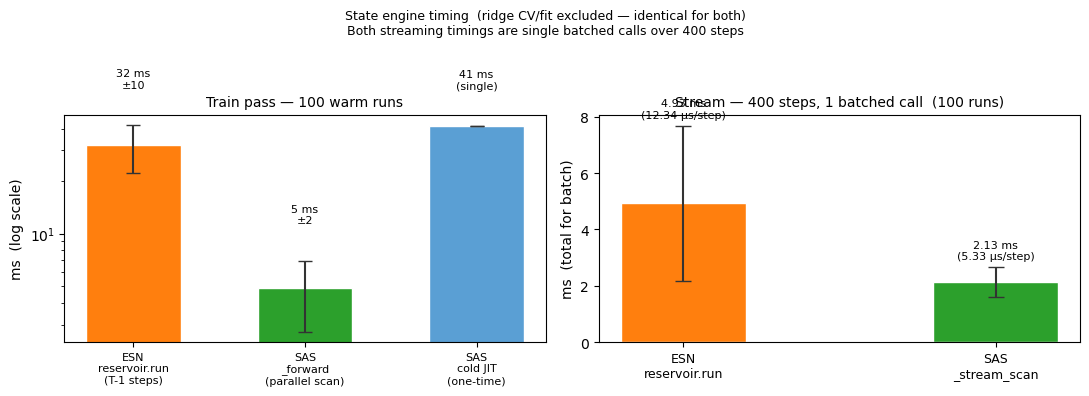

In [28]:
# ── Timing — state engine only (bar chart, log scale) ────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: training pass ───────────────────────────────────────────────────
x1 = [0, 1, 2]
h1 = [esn_efit_mu*1e3, sas_efit_mu*1e3, t_sas_cold*1e3]
e1 = [esn_efit_sd*1e3, sas_efit_sd*1e3, 0]
c1 = ["tab:orange", "tab:green", "#5a9fd4"]
l1 = ["ESN\nreservoir.run\n(T-1 steps)", "SAS\n_forward\n(parallel scan)", "SAS\ncold JIT\n(one-time)"]

bars = ax1.bar(x1, h1, color=c1, width=0.55, edgecolor="white",
               yerr=e1, capsize=5, error_kw=dict(linewidth=1.5, ecolor="#333"))
ax1.set_yscale("log")
ax1.set_xticks(x1); ax1.set_xticklabels(l1, fontsize=8)
ax1.set_ylabel("ms  (log scale)")
ax1.set_title(f"Train pass — {N_EVAL} warm runs", fontsize=10)
for bar, h, e in zip(bars, h1, e1):
    tag = f"{h:.0f} ms" + (f"\n±{e:.0f}" if e > 0 else "\n(single)")
    ax1.text(bar.get_x() + bar.get_width()/2, max(h + e, h) * 1.6,
             tag, ha="center", va="bottom", fontsize=8)

# ── Right: streaming — TOTAL ms for T_TEST steps, 1 batched call each ────
# ESN : reservoir.run(X_tr[-1:]) + reservoir.run(X_te[:-1])  — NumPy C loop
# SAS : _stream_scan via lax.scan                             — XLA compiled
# Both are single-dispatch batched calls → apples-to-apples comparison.
x2 = [0, 1]
h2 = [esn_estr_mu*1e3, sas_estr_mu*1e3]          # total ms
e2 = [esn_estr_sd*1e3, sas_estr_sd*1e3]
c2 = ["tab:orange", "tab:green"]
l2 = [f"ESN\nreservoir.run", f"SAS\n_stream_scan"]

bars2 = ax2.bar(x2, h2, color=c2, width=0.4, edgecolor="white",
                yerr=e2, capsize=6, error_kw=dict(linewidth=1.5, ecolor="#333"))
ax2.set_xticks(x2); ax2.set_xticklabels(l2, fontsize=9)
ax2.set_ylabel("ms  (total for batch)")
ax2.set_title(f"Stream — {T_TEST} steps, 1 batched call  ({N_EVAL} runs)", fontsize=10)
for bar, h, e in zip(bars2, h2, e2):
    per_step = h / T_TEST * 1e3   # µs/step
    ax2.text(bar.get_x() + bar.get_width()/2, h + e + max(h2)*0.04,
             f"{h:.2f} ms\n({per_step:.2f} µs/step)", ha="center", va="bottom", fontsize=8)

plt.suptitle(
    "State engine timing  (ridge CV/fit excluded — identical for both)\n"
    f"Both streaming timings are single batched calls over {T_TEST} steps",
    fontsize=9)
plt.tight_layout()
plt.show()

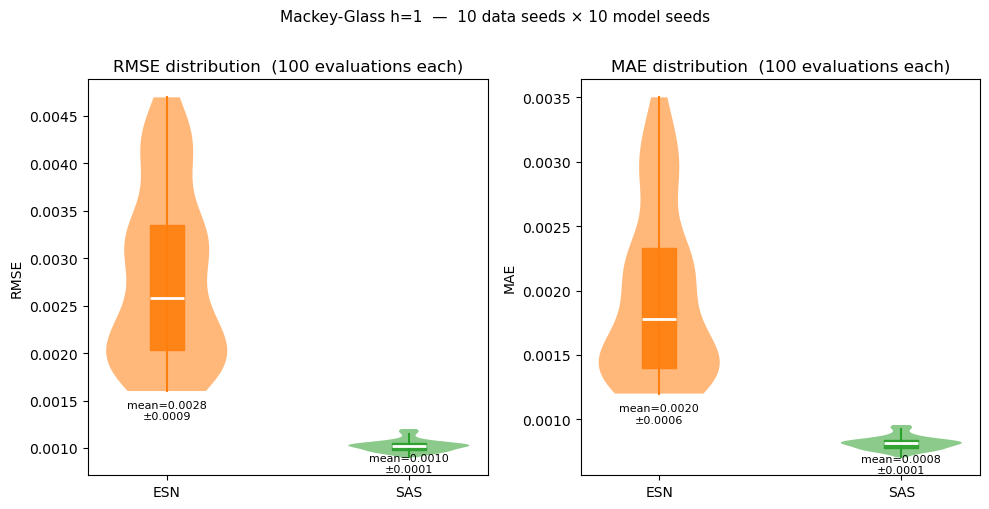

In [29]:
# ── Accuracy — violin + box plot (1 000 evaluations each) ─────────────────────
esn_rmse_all = np.array([r["rmse"] for r in all_esn])
sas_rmse_all = np.array([r["rmse"] for r in all_sas])
esn_mae_all  = np.array([r["mae"]  for r in all_esn])
sas_mae_all  = np.array([r["mae"]  for r in all_sas])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, e_vals, s_vals, metric in zip(
    axes,
    [esn_rmse_all, esn_mae_all],
    [sas_rmse_all, sas_mae_all],
    ["RMSE", "MAE"],
):
    parts = ax.violinplot(
        [e_vals, s_vals], positions=[0, 1],
        showmedians=False, showextrema=False,
    )
    for pc, color in zip(parts["bodies"], ["tab:orange", "tab:green"]):
        pc.set_facecolor(color)
        pc.set_alpha(0.55)

    # box-plot overlay (quartiles + median)
    for i, vals, color in zip([0, 1], [e_vals, s_vals], ["tab:orange", "tab:green"]):
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        iqr = q3 - q1
        lo  = max(vals.min(), q1 - 1.5 * iqr)
        hi  = min(vals.max(), q3 + 1.5 * iqr)
        ax.plot([i, i], [lo, hi], color=color, lw=1.5, zorder=3)   # whisker
        ax.fill_between([i - 0.07, i + 0.07], q1, q3,
                        color=color, alpha=0.9, zorder=4)          # IQR box
        ax.hlines(med, i - 0.07, i + 0.07, colors="white",
                  linewidth=2, zorder=5)                           # median
        # mean annotation
        mu, sd = vals.mean(), vals.std()
        ax.text(i, lo - 0.2*lo,
                f"mean={mu:.4f}\n±{sd:.4f}",
                ha="center", va="bottom", fontsize=8)

    ax.set_xticks([0, 1]); ax.set_xticklabels(["ESN", "SAS"])
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} distribution  ({N_EVAL} evaluations each)")

plt.suptitle(
    f"Mackey-Glass h=1  —  {len(DATA_SEEDS)} data seeds × {len(MODEL_SEEDS)} model seeds",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()